# **Business problem**

a global e commerce company operating across multiple regions manages end to end order fulfillment, including shipping and delivery for products like sporting goods. company is facing inconsistent delivery performance, where actula shipping times often deviate from actual shipping timeline leading to late deliveries and unpredictable order profitability.

**A Desired Outcome**

the goal is analyze delivery opertaions, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping performance, and improve overall performance and efficiency

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors=cm.viridis(np.linspace(0,1,5))
primary_colour=viridis_colors[0]
secondary_color=viridis_colors[1]
accent_color= viridis_colors[2]
danger_color = '#800000'
neutral_colors = viridis_colors[4]
custom_palette = viridis_colors


In [5]:
df = pd.read_csv('/content/drive/MyDrive/DataCoSupplyChainDataset(4).csv', encoding= 'latin-1')

In [6]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [7]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


**Exploratory Data Analysis**

In [8]:
print('rows, cols:', df.shape)
print('\ncolumns: ')
print(df.columns.tolist())
print('\nNum duplicates: ', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns: 
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produ

In [9]:
df['Benefit per order'] == df['Order Profit Per Order']

,0
0,True
1,True
2,True
3,True
4,True
...,...
180514,True
180515,True
180516,True
180517,True


In [10]:
df['Product Status'].value_counts()

,count
Product Status,
0,180519


In [11]:
#data cleaning

columns_to_drop = [
    'Product Description', # Corrected from 'Products description'
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id', # Corrected: Removed trailing space
    'Product Card Id',
    'Product Category Id',
    'Benefit per order', # Corrected from 'Benefits per order'
    'Product Status', # Corrected from 'product Status'
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'

]

#dropping columns that are either fully missing , redundant, or have only one value(and thus no variance)
df = df.drop(columns=columns_to_drop)

#removing canceld orders since they are not relavant for delivery time analysis and may have different patterns thatn completed orders
df = df[df['Delivery Status'] != 'Shipping Canceled']

#standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst=False)

#after data cleaning
print('rows, cols:', df.shape)
print('\ncolumns: ')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 21)

columns: 
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer Country                 0
Customer Id                      0
Customer Segment                 0
Department Name                  0
order date (DateOrders)          0
Order Item Profit Ratio          0
Sales                            0
Order Profit Per Order           0
Order Region                     0
Order Status                     0
Product Name                     0
Product Price                    0
shipping date (DateOrders)       0
dtype: int64


In [12]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Id,Customer Segment,...,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,20755,Consumer,...,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,19492,Consumer,...,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,19491,Consumer,...,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,19490,Home Office,...,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,19489,Corporate,...,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [13]:
#value counts for cateforical coloumns with low cardinality
for col in df.columns:
  if df[col].nunique()<10:
    print(f'\n{col} value counts: ')
    print(df[col].value_counts())


Type value counts: 
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts: 
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled) value counts: 
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status value counts: 
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk value counts: 
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country value counts: 
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment value counts: 
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Status 

In [14]:
df['Order_processing_time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order_processing_time'] - df ['Days for shipment (scheduled)']

df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,Customer Id,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order_processing_time,Delay,order_month,order_hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,183.107609,0.548291,6691.379495,2016-06-12 17:47:04.669868544,0.120647,203.772096,21.974989,141.232550,2016-06-16 05:45:23.202433024,3.471856,0.540010,6.235449,11.483689
min,0.000000,0.000000,7.490000,0.000000,1.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,3258.500000,2015-09-21 13:49:00,0.080000,119.980003,7.000000,50.000000,2015-09-25 06:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,6457.000000,2016-06-11 13:06:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 08:32:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,9779.000000,2017-03-01 08:42:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 21:29:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,20757.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623722,1.374449,120.043670,0.497664,4162.918106,NaN,0.466796,132.273077,104.433526,139.732492,NaN,1.670471,1.491881,3.403571,6.923006


In [15]:
df['Is_Delayed'].value_counts()

,count
Is_Delayed,
True,98743
False,81776


In [16]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Id', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order_processing_time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [17]:
df['Order Profit Per Order'] > 0

,Order Profit Per Order
0,True
1,False
2,False
3,True
4,True
...,...
180514,True
180515,False
180516,True
180517,True


In [18]:
df['Profitabilty Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss','Break-even'))
df['Profitabilty Flag'].value_counts()

,count
Profitabilty Flag,
Profit,145558
Loss,33784
Break-even,1177


In [19]:
df['Profitabilty Flag'].value_counts(normalize=True)

,proportion
Profitabilty Flag,
Profit,0.806331
Loss,0.187149
Break-even,0.006520


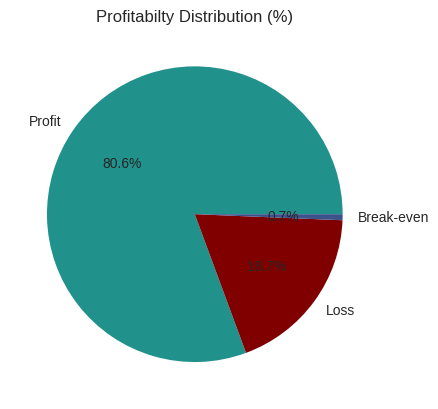

In [20]:
#visualization of profitability distribution
profit_counts = df['Profitabilty Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind = 'pie', autopct='%1.1f%%',  colors=[accent_color, danger_color,secondary_color])
plt.ylabel('')
plt.title('Profitabilty Distribution (%)')
plt.show()

In [21]:
def format_func(value):
  if value >= 1e6:
    return f'{value/1e6:.1f}M.$'
  elif value >= 1e3:
    return f'{value/1e3:.1f}K $'
  else:
    return f'{value:.0f} $'

delayed_df= df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time delivery'] = (1- float(metrics['Late Deliveries']/metrics['Total Orders']))*100
metrics['Late Deliveries %'] = float(metrics['Late Deliveries']/metrics['Total Orders'])*100
metrics['Total profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0 , 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0 , 'Order Profit Per Order'].sum())

print('\n---- Buisness KPIs------\n')
for k, v in metrics.items():
  if isinstance(v, float):
    print(f"{k}: {v:.2f}")
  else:
    print(f"{k}: {v}")



---- Buisness KPIs------

Total Orders: 180519
Late Deliveries: 98743
90% Delay (days): 3.00
On time delivery: 45.30
Late Deliveries %: 54.70
Total profit: 7.9M.$
Total Loss due to delays: 2.1M.$


# Profitablity vs Delivery time analysis

In [22]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    )
    .reset_index()
)

In [23]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.423528,5.074942e+05,21666
1,-1,21.516997,4.669188e+05,21700
2,0,22.044854,8.467429e+05,38410
3,1,22.225592,1.244411e+06,55990
4,2,21.246239,6.101495e+05,28718
5,3,19.941130,1.406248e+05,7052
6,4,21.561202,1.505619e+05,6983


In [24]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize= True )
    .sort_index() * 100
).reset_index()

In [25]:
delay_distribution

,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291



profit metrics by Delay day :


,Delay_Days,Percenatge
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291



Delay Distribution (%): 


,Delay_Days,Percenatge
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


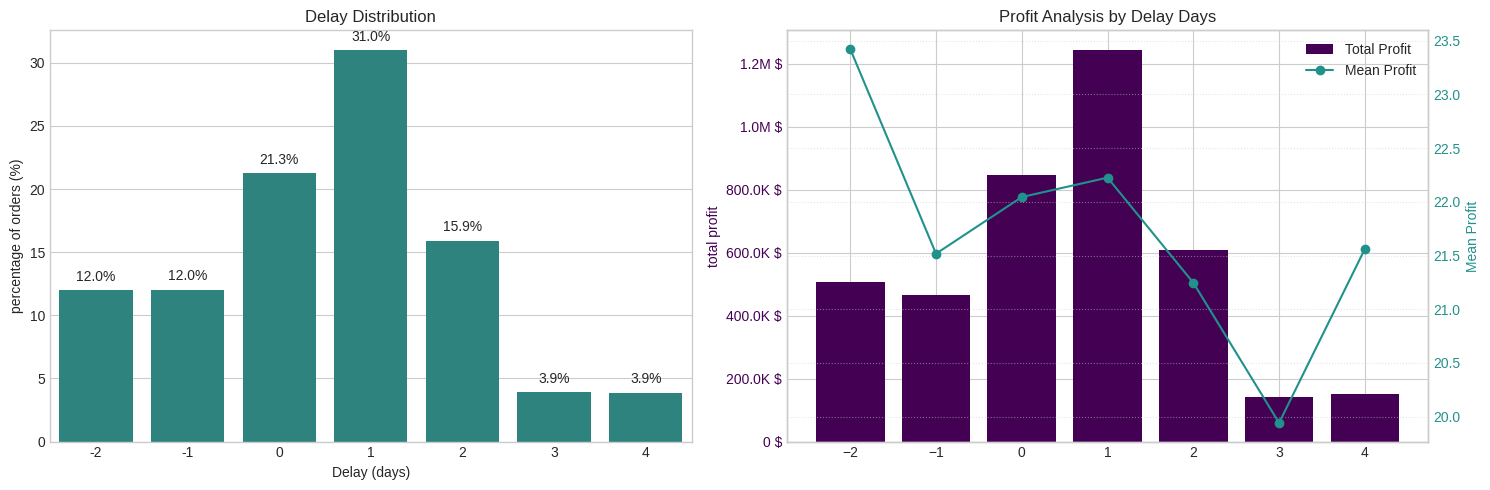

In [26]:
delay_distribution.columns = ['Delay_Days' , 'Percenatge']

print("\nprofit metrics by Delay day :")
display(delay_distribution)

print("\nDelay Distribution (%): ")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))

#first subplot: DELAY DISTRIBUTION
sns.barplot(x='Delay_Days', y='Percenatge', data = delay_distribution, color = accent_color, ax= ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

#percentage text on bars

for bar in ax1.patches:
  height = bar.get_height()
  ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha = 'center', va = 'bottom')

#second plot : PROFIT ANALYSIS BY DELAY DAYS
ax2.set_ylabel("total profit", color= primary_colour)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color= primary_colour, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_colour)

ax3= ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'],marker='o', color=accent_color, label='Mean Profit')
ax3.tick_params(axis='y', labelcolor=accent_color)


#format total profit axis to K $ , M $
def format_func(value, tick_number):
  if value >= 1e6:
    return f'{value/1e6:.1f}M $'
  elif value >= 1e3:
    return f'{value/1e3:.1f}K $'
  else:
    return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

# Get handles and labels from both axes
handles1, labels1 = ax2.get_legend_handles_labels()
handles2, labels2 = ax3.get_legend_handles_labels()

ax3.set_title("Profit Analysis by Delay Days")
ax3.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Bottleneck Detection

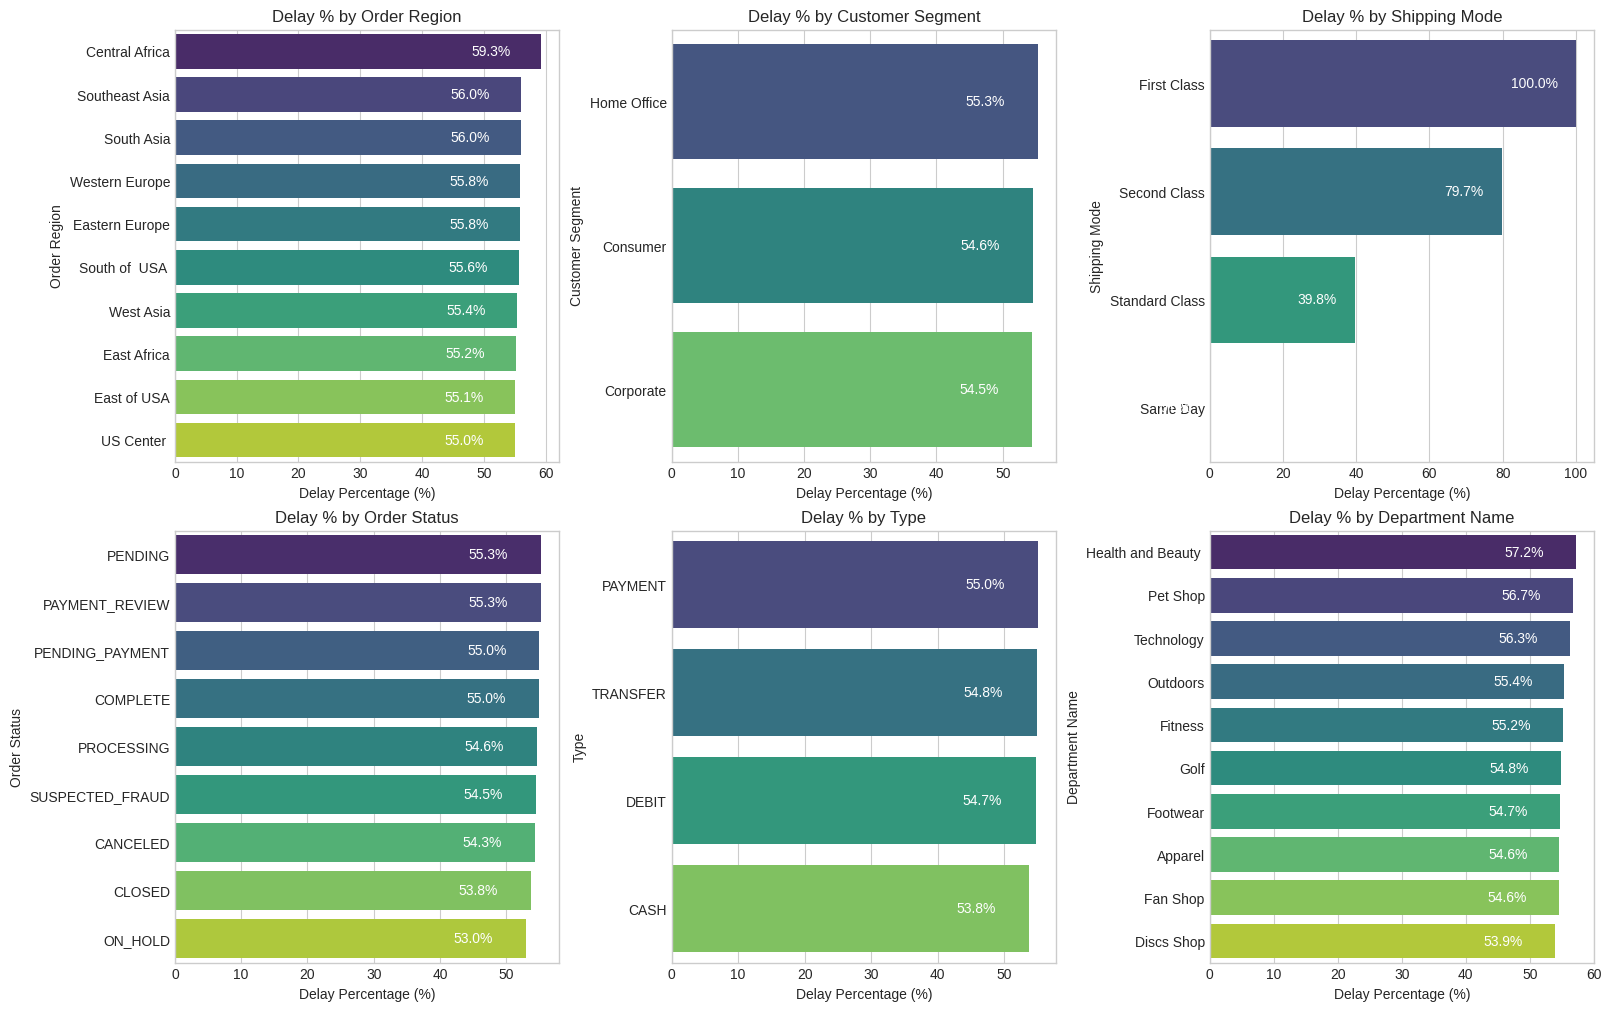

In [27]:
import matplotlib.ticker as ticker

def compute_delay_pct_by_category(category):
  cat_df = df.groupby(category).agg(
      total_orders = ('Delay','count'),
      late_orders = ('Is_Delayed', 'sum')
  ).reset_index()
  cat_df['delay_pct'] = cat_df['late_orders']/cat_df['total_orders']*100
  cat_df = cat_df.sort_values(by='delay_pct', ascending=False).head(10)
  return cat_df

categories= ['Order Region','Customer Segment','Shipping Mode','Order Status','Type','Department Name']

fig, axes = plt.subplots(2,3, figsize=(16,10), constrained_layout=True) # Increased figsize for better readability
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data = cat_df,
        x = 'delay_pct',
        y = category,
        ax = ax,
        palette = 'viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('Delay Percentage (%)')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows(): # Corrected loop syntax
      ax.text(row['delay_pct'] - 5, i, f"{row['delay_pct']:.1f}%", va = 'center', ha='right', fontsize=10,color='white') # Adjusted text position

plt.show()

In [28]:
def compute_delay_pct_by_category(category):
  cat_df = df.groupby(category).agg(
      total_orders = ('Delay','count'),
      late_orders = ('Is_Delayed', 'sum')
  ).reset_index()
  cat_df['delay_pct'] = cat_df['late_orders']/cat_df['total_orders']*100
  cat_df=cat_df.sort_values(by='delay_pct', ascending=False).head(10)
  return cat_df



In [29]:
compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
2,Home Office,32226,17821,55.300068
0,Consumer,93504,51071,54.619054
1,Corporate,54789,29851,54.483564


# Root cause analysis

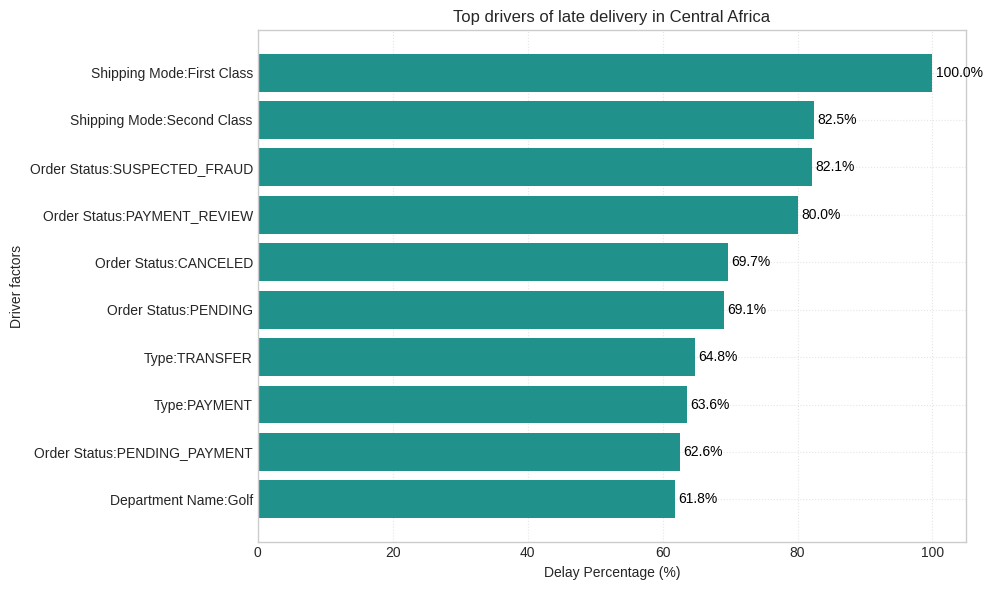

In [30]:
#top drivers of late delivery by region

def top_drivers_for_region(region):
  df_region = df[df['Order Region'] == region].copy()

  # Corrected typos in drivers list
  drivers = ['Shipping Mode', 'Customer Segment', 'Department Name','Type','Order Status']

  all_factors=[]
  for factor in drivers:
    # Ensure the factor exists in the DataFrame before grouping
    if factor in df_region.columns:
      temp = (
          df_region.groupby(factor)
          .agg(
              total_orders = ('Delay', 'count'),
              late_orders = ('Is_Delayed', 'sum'),
              avg_delays = ('Delay','mean')
          )
          .reset_index()
      )

      temp['Delay_pct'] = temp['late_orders']/temp['total_orders']*100
      temp['Driver'] = factor
      # Ensure factor is string type before concatenation
      temp['Factor_level']= factor + ":" + temp[factor].astype(str)

      # Corrected column name 'avg_delay' to 'avg_delays'
      all_factors.append(temp[['Driver', 'Factor_level','Delay_pct','avg_delays','total_orders']])

  # Combine all drivers (moved inside the function)
  final_df = pd.concat(all_factors)

  #top 10 drivers
  top_factors = final_df.sort_values(by='Delay_pct', ascending=False).head(10)

  plt.figure(figsize=(10, 6))
  bars = plt.barh(top_factors['Factor_level'], top_factors['Delay_pct'], color=accent_color)

  plt.xlabel("Delay Percentage (%)")
  plt.ylabel("Driver factors")
  plt.title(f"Top drivers of late delivery in {region}")
  plt.grid(True, linestyle=':', alpha=0.5)
  plt.gca().invert_yaxis() # Invert y-axis to have the highest percentage at the top

  for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             fontsize = 10, color = 'black' , va='center', ha='left') # Adjusted text position and color

  plt.tight_layout()
  plt.show()


top_drivers_for_region('Central Africa')

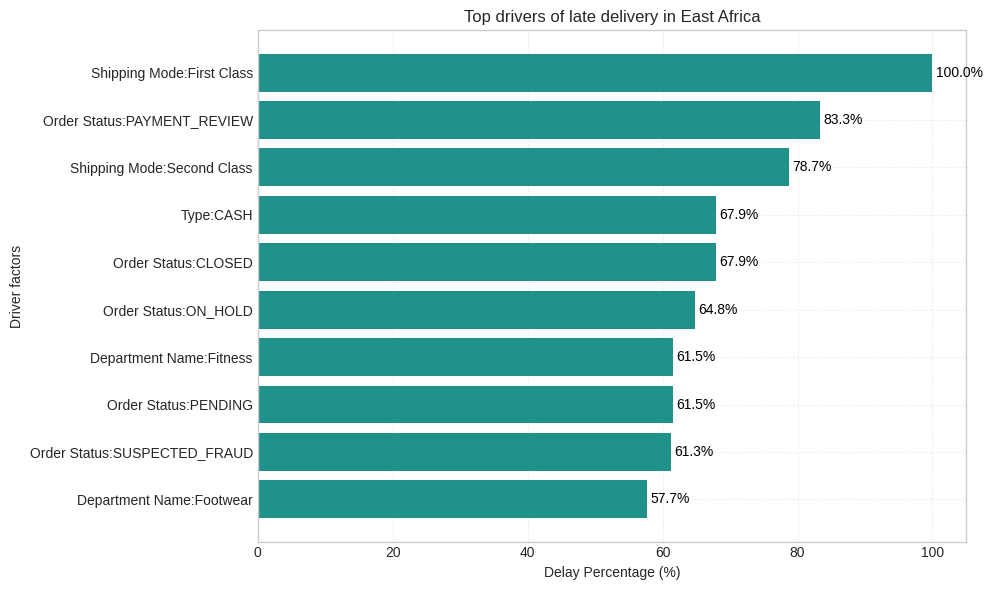

In [31]:
top_drivers_for_region('East Africa')

# Time Series analysis

In [32]:
df['shipping date (DateOrders)'].min()

Timestamp('2015-01-03 00:00:00')

In [33]:
df['shipping date (DateOrders)'].max()

Timestamp('2018-02-06 22:14:00')

In [34]:
#delay % by month , day of week , hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()

)

delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day =(
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour=(
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100



In [35]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.541743,54.174314
1,2,0.545736,54.573611
2,3,0.549029,54.902946
3,4,0.544542,54.454163
4,5,0.550388,55.038808
5,6,0.545016,54.501618
6,7,0.541201,54.120085
7,8,0.552916,55.291604
8,9,0.552327,55.232746
9,10,0.541953,54.195291


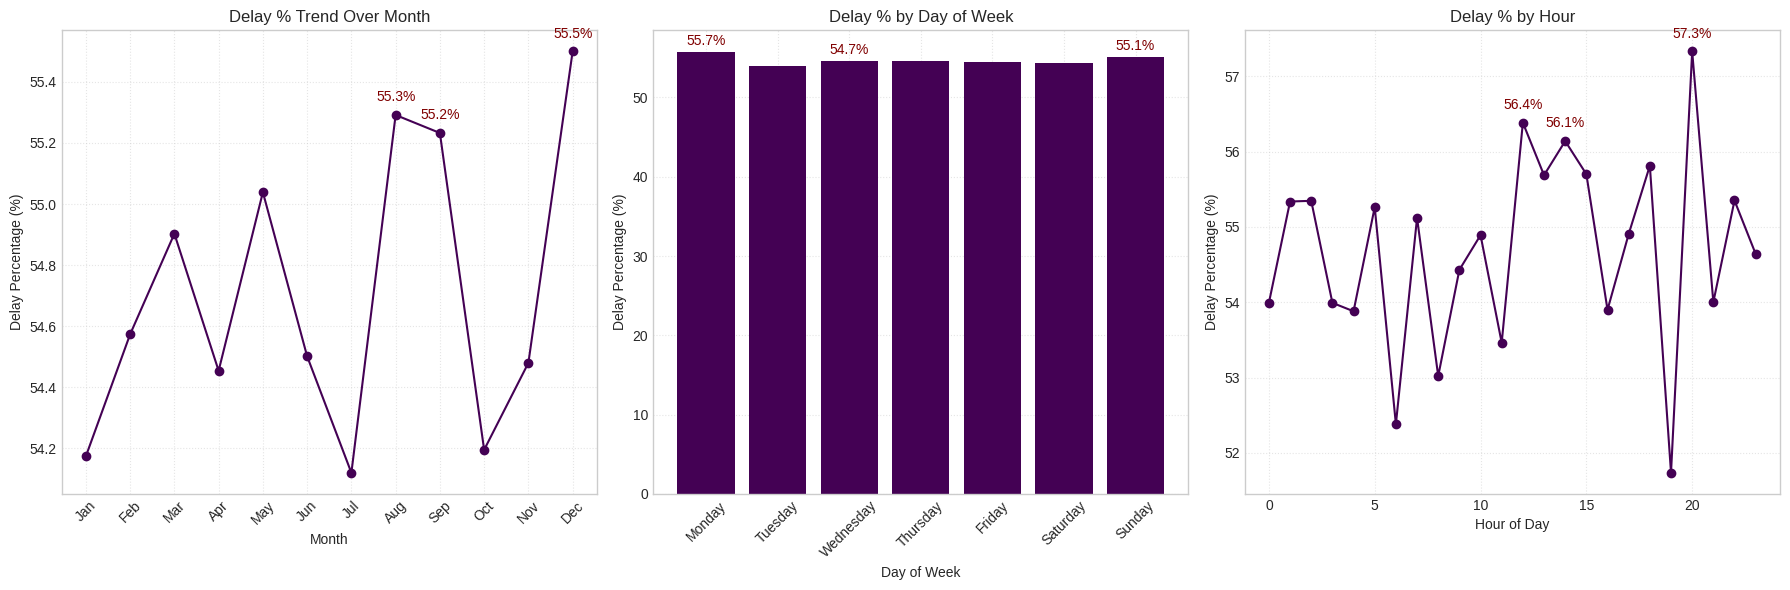

In [36]:
# Initialize the figure with 3 subplots side-by-side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# -------------------------------------------------------------------------
# Subplot 1: Delay % Trend Over Month
# -------------------------------------------------------------------------
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_colour)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# -------------------------------------------------------------------------
# Subplot 2: Delay % by Day of Week
# -------------------------------------------------------------------------
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_colour)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# -------------------------------------------------------------------------
# Subplot 3: Delay % by Hour
# -------------------------------------------------------------------------
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_colour)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# Render layout
plt.tight_layout()
plt.show()

# Machine learning modeling

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [39]:
X = df[['Type' , 'Days for shipment (scheduled)','Category Name','Customer Segment','Department Name','Order Region','Shipping Mode','order_month','order_hour']]
y= df['Late_delivery_risk']

In [41]:
cat_cols = X.select_dtypes(include = ['object','category']).columns.tolist()
print('Categorical coloumns: ', cat_cols)

#frequency encoding (low dimensional and robust for hight cardinality)
for col in cat_cols:
  freq = X[col].value_counts(normalize=True)
  X[f'{col}_freq'] = X[col].map(freq)


#keep numneric columns + new encoded features , drop original string categories
X_encoded = X.drop(columns= cat_cols)
print('Shape after freq + target encoding: ', X_encoded.shape)

#use encoded features for modelling
X=X_encoded

#train/test split after encoding

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2, random_state= 42, stratify=y
)


Categorical coloumns:  ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq + target encoding:  (180519, 9)


In [42]:
y.value_counts()

,count
Late_delivery_risk,
1,98977
0,81542


In [43]:
#balancing the train data using SMOTE
print("before balancing train: ", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("after balancing train: ", Counter(y_train_bal))

before balancing train:  Counter({1: 79181, 0: 65234})
after balancing train:  Counter({1: 79181, 0: 79181})


In [48]:
def evaluate_model(y_true, y_pred, model_name):
  print(f"Model: {model_name}")
  print("Accuracy: ",round(accuracy_score(y_true, y_pred),2))
  print("Precision: ",round(precision_score(y_true, y_pred),2))
  print("Recall: ",round(recall_score(y_true, y_pred),2))
  print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [49]:
#fit random forest model to the balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(y_test, y_pred_rf_balanced,"Random Forest Classifier")

Model: Random Forest Classifier
Accuracy:  0.73
Precision:  0.77
Recall:  0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.73      0.71     16308
           1       0.77      0.74      0.75     19796

    accuracy                           0.73     36104
   macro avg       0.73      0.73      0.73     36104
weighted avg       0.74      0.73      0.73     36104

